# 03 - Classical Baselines

## Goal
Set honest non-neural baselines on the held-out test split before moving to LSTM/XGBoost tuning.

Models here:
- Naive last value
- Seasonal naive
- ARIMA
- Ridge
- Lasso

In [1]:
from pathlib import Path
import sys
import json
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.project_utils import ensure_project_dirs, seed_everything

seed_everything(42)
paths = ensure_project_dirs()
base_dir = paths["results"] / "baselines"
base_dir.mkdir(parents=True, exist_ok=True)

pd.options.display.max_columns = 200

print("Repo root:", ROOT)
print("Baselines dir:", base_dir)

Repo root: C:\Users\jijos\Desktop\261-Project
Baselines dir: C:\Users\jijos\Desktop\261-Project\results\baselines


## Config
- `N_LAGS` default: 24 months.
- ARIMA order is tuned on validation from a small grid.
- Linear models can fit on target `level` or on `delta = y - Inflation_prev`.
- MASE still uses only in-sample history (`train + val`).


In [2]:
N_LAGS = 24
SEASONAL_PERIOD = 12
MASE_M = 1
LINEAR_TARGET_MODE = "delta"   # options: "level", "delta"

ARIMA_GRID = [(1,0,0), (2,0,0), (1,0,1), (2,0,1), (1,1,0)]
RIDGE_ALPHA_GRID = [1e-4,1e-3,1e-2,1e-1,1,3,10,30,100]
LASSO_ALPHA_GRID = [1e-4,5e-4,1e-3,5e-3,1e-2,5e-2,1e-1]

print("N_LAGS:", N_LAGS)
print("Linear target mode:", LINEAR_TARGET_MODE)
print("ARIMA grid:", ARIMA_GRID)


N_LAGS: 24
Linear target mode: delta
ARIMA grid: [(1, 0, 0), (2, 0, 0), (1, 0, 1), (2, 0, 1), (1, 1, 0)]


## Load modeling table and split metadata
Inputs from notebook 02:
- `data/processed/modeling_table_full.csv`
- `data/processed/split_metadata.json`

If specific feature-set table is missing, notebook falls back to available table and filters to metadata features.

In [3]:
split_meta_path = paths["processed_data"] / "split_metadata.json"
if not split_meta_path.exists():
    raise FileNotFoundError("Missing split metadata. Run notebook 02 first.")
split_meta = json.loads(split_meta_path.read_text(encoding="utf-8"))

preferred_table = paths["processed_data"] / "modeling_table_full.csv"
if preferred_table.exists():
    model_path = preferred_table
else:
    candidates = sorted(paths["processed_data"].glob("modeling_table_*.csv"))
    if not candidates:
        raise FileNotFoundError("No modeling table found. Run notebook 02 first.")
    model_path = candidates[0]

model_df = pd.read_csv(model_path, index_col=0, parse_dates=True).sort_index()

TARGET_NAME = split_meta["target_name"]
if TARGET_NAME not in model_df.columns:
    raise KeyError(f"Target {TARGET_NAME} not found in modeling table")

selected_features = split_meta.get("selected_features", [c for c in model_df.columns if c != TARGET_NAME])
selected_features = [c for c in selected_features if c in model_df.columns and c != TARGET_NAME]

train_end = int(split_meta["boundaries"]["train_end_idx"])
val_end = int(split_meta["boundaries"]["val_end_idx"])

if not (0 < train_end < val_end < len(model_df)):
    raise ValueError("Invalid split boundaries from metadata")

X_df = model_df[selected_features].copy()
y_sr = model_df[TARGET_NAME].copy()

y_train = y_sr.iloc[:train_end]
y_val = y_sr.iloc[train_end:val_end]
y_test = y_sr.iloc[val_end:]
y_insample = y_sr.iloc[:val_end]  # used for MASE scale only

print("Model table:", model_path)
print("Rows:", len(model_df), "Features:", len(selected_features))
print("Target:", TARGET_NAME)
print("Split rows:", {"train": len(y_train), "val": len(y_val), "test": len(y_test)})

Model table: C:\Users\jijos\Desktop\261-Project\data\processed\modeling_table_full.csv
Rows: 395 Features: 22
Target: target_yoy_t_plus_1
Split rows: {'train': 347, 'val': 24, 'test': 24}


## Metrics
All reported metrics are on the true held-out test segment.

MASE details:
- denominator uses in-sample history only (`train + val`)
- no test information is used in scaling

In [4]:
def mae(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))


def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom))


def mase(y_true, y_pred, y_insample, m=1, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_insample = np.asarray(y_insample)
    if len(y_insample) <= m:
        return float("nan")
    scale = np.mean(np.abs(y_insample[m:] - y_insample[:-m]))
    return float(np.mean(np.abs(y_true - y_pred)) / (scale + eps))


def evaluate_model(name, y_true, y_pred, y_insample, mase_m=1):
    return {
        "model": name,
        "mae": mae(y_true, y_pred),
        "smape": smape(y_true, y_pred),
        "mase": mase(y_true, y_pred, y_insample, m=mase_m),
    }


print("MASE scale history length (train+val only):", len(y_insample))

MASE scale history length (train+val only): 371


## Time-series baselines
- **Naive last**: previous observed target
- **Seasonal naive**: value from 12 months ago
- **ARIMA**: pick order with lowest validation MAE, then refit on train+val and score on test


In [5]:
# Naive baselines from target history
y_naive_last = y_sr.shift(1).loc[y_test.index]
y_naive_seasonal = y_sr.shift(SEASONAL_PERIOD).loc[y_test.index]

def aligned_eval(y_true_sr, y_pred_sr):
    joint = pd.concat([y_true_sr.rename("y"), y_pred_sr.rename("p")], axis=1).dropna()
    return joint["y"], joint["p"]

# quick ARIMA order search on validation only
arima_val_rows = []
for order in ARIMA_GRID:
    try:
        mdl = ARIMA(y_train, order=order)
        fit = mdl.fit()
        pred_val = pd.Series(fit.forecast(steps=len(y_val)), index=y_val.index)
        y_tv, y_pv = aligned_eval(y_val, pred_val)
        v_mae = mae(y_tv, y_pv)
        arima_val_rows.append({"order": order, "val_mae": float(v_mae)})
    except Exception:
        continue

if len(arima_val_rows) == 0:
    raise RuntimeError("ARIMA search failed for all candidate orders")

arima_val_df = pd.DataFrame(arima_val_rows).sort_values("val_mae").reset_index(drop=True)
best_arima_order = tuple(arima_val_df.iloc[0]["order"])

# refit best order on train+val and evaluate on held-out test
arima_fit = ARIMA(y_insample, order=best_arima_order).fit()
y_arima = pd.Series(arima_fit.forecast(steps=len(y_test)), index=y_test.index)

y_t_last, y_p_last = aligned_eval(y_test, y_naive_last)
y_t_seas, y_p_seas = aligned_eval(y_test, y_naive_seasonal)
y_t_arima, y_p_arima = aligned_eval(y_test, y_arima)

metrics_ts = []
metrics_ts.append(evaluate_model("NaiveLast", y_t_last, y_p_last, y_insample, mase_m=MASE_M))
metrics_ts.append(evaluate_model("SeasonalNaive", y_t_seas, y_p_seas, y_insample, mase_m=MASE_M))
metrics_ts.append(evaluate_model(f"ARIMA{best_arima_order}", y_t_arima, y_p_arima, y_insample, mase_m=MASE_M))

display(arima_val_df)
pd.DataFrame(metrics_ts).sort_values("mae")


C:\Users\jijos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\jijos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\jijos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


C:\Users\jijos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\jijos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\jijos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\jijos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\jijos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  

C:\Users\jijos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\jijos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\jijos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


C:\Users\jijos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\jijos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\jijos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\jijos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\jijos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  

,order,val_mae
0,"(1, 0, 0)",1.456836
1,"(1, 0, 1)",1.641255
2,"(1, 1, 0)",2.009769
3,"(2, 0, 1)",2.066587
4,"(2, 0, 0)",2.387805


,model,mae,smape,mase
0,NaiveLast,0.178702,6.368292,0.617544
2,"ARIMA(1, 0, 0)",0.316067,11.021485,1.092239
1,SeasonalNaive,0.845264,24.189188,2.920992


## Ridge/Lasso with lag-window representations
We keep the two required formats:
1. `mean_pooled`
2. `flattened`

Both are tuned with validation MAE, then refit on train+val before test metrics.


In [6]:
def build_tabular_windows(X_df, y_sr, n_lags=24, representation="mean_pooled"):
    x = X_df.values
    y = y_sr.values
    idx = X_df.index
    p = X_df["Inflation_prev"].values

    X_out, y_out, p_out, idx_out = [], [], [], []
    for i in range(n_lags, len(X_df)):
        block = x[i-n_lags:i, :]
        if representation == "mean_pooled":
            feat = block.mean(axis=0)
        elif representation == "flattened":
            feat = block.reshape(-1)
        else:
            raise ValueError("representation must be mean_pooled or flattened")

        X_out.append(feat)
        y_out.append(y[i])
        p_out.append(p[i])
        idx_out.append(idx[i])

    return np.asarray(X_out), np.asarray(y_out), np.asarray(p_out), pd.Index(idx_out)


def split_by_index_boundary(X_all, y_all, p_all, idx_all, train_end_idx, val_end_idx):
    train_mask = idx_all < y_sr.index[train_end_idx]
    val_mask = (idx_all >= y_sr.index[train_end_idx]) & (idx_all < y_sr.index[val_end_idx])
    test_mask = idx_all >= y_sr.index[val_end_idx]

    return (
        X_all[train_mask], y_all[train_mask], p_all[train_mask],
        X_all[val_mask], y_all[val_mask], p_all[val_mask],
        X_all[test_mask], y_all[test_mask], p_all[test_mask], idx_all[test_mask],
    )


rep_results = []
final_linear_metrics = []
pred_store = {}

for model_name in ["Ridge", "Lasso"]:
    val_scores = {}
    rep_cache = {}
    chosen_alpha = {}

    for rep in ["mean_pooled", "flattened"]:
        X_all, y_all, p_all, idx_all = build_tabular_windows(X_df, y_sr, n_lags=N_LAGS, representation=rep)
        X_tr, y_tr, p_tr, X_va, y_va, p_va, X_te, y_te, p_te, idx_te = split_by_index_boundary(
            X_all, y_all, p_all, idx_all, train_end, val_end
        )

        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_va_sc = scaler.transform(X_va)

        if LINEAR_TARGET_MODE == "delta":
            y_tr_fit = y_tr - p_tr
            y_va_fit = y_va - p_va
        else:
            y_tr_fit = y_tr
            y_va_fit = y_va

        if model_name == "Ridge":
            grid = RIDGE_ALPHA_GRID
            build_model = lambda a: Ridge(alpha=a)
        else:
            grid = LASSO_ALPHA_GRID
            build_model = lambda a: Lasso(alpha=a, max_iter=50000, random_state=42)

        best_alpha = None
        best_val = float("inf")

        for alpha in grid:
            mdl = build_model(alpha)
            mdl.fit(X_tr_sc, y_tr_fit)
            pred_va_fit = mdl.predict(X_va_sc)
            if LINEAR_TARGET_MODE == "delta":
                pred_va = p_va + pred_va_fit
            else:
                pred_va = pred_va_fit

            v = mae(y_va, pred_va)
            if v < best_val:
                best_val = float(v)
                best_alpha = float(alpha)

        val_scores[rep] = best_val
        chosen_alpha[rep] = best_alpha
        rep_cache[rep] = (X_all, y_all, p_all, idx_all)

        rep_results.append({
            "model_family": model_name,
            "representation": rep,
            "val_mae": float(best_val),
            "best_alpha": float(best_alpha),
            "n_features_after_rep": int(X_tr.shape[1]),
            "n_train_windows": int(len(y_tr)),
            "n_val_windows": int(len(y_va)),
            "n_test_windows": int(len(y_te)),
            "fit_target_mode": LINEAR_TARGET_MODE,
        })

    best_rep = min(val_scores, key=val_scores.get)

    X_all, y_all, p_all, idx_all = rep_cache[best_rep]
    trainval_mask = idx_all < y_sr.index[val_end]
    test_mask = idx_all >= y_sr.index[val_end]

    X_trainval = X_all[trainval_mask]
    y_trainval = y_all[trainval_mask]
    p_trainval = p_all[trainval_mask]

    X_test_rep = X_all[test_mask]
    y_test_rep = y_all[test_mask]
    p_test_rep = p_all[test_mask]
    idx_test_rep = idx_all[test_mask]

    scaler = StandardScaler()
    X_trainval_sc = scaler.fit_transform(X_trainval)
    X_test_rep_sc = scaler.transform(X_test_rep)

    alpha = chosen_alpha[best_rep]
    if model_name == "Ridge":
        final_model = Ridge(alpha=alpha)
    else:
        final_model = Lasso(alpha=alpha, max_iter=50000, random_state=42)

    if LINEAR_TARGET_MODE == "delta":
        y_trainval_fit = y_trainval - p_trainval
    else:
        y_trainval_fit = y_trainval

    final_model.fit(X_trainval_sc, y_trainval_fit)
    pred_test_fit = final_model.predict(X_test_rep_sc)

    if LINEAR_TARGET_MODE == "delta":
        pred_test = p_test_rep + pred_test_fit
    else:
        pred_test = pred_test_fit

    lo = float(np.quantile(y_trainval, 0.01))
    hi = float(np.quantile(y_trainval, 0.99))
    pred_test = np.clip(pred_test, lo, hi)

    row = evaluate_model(f"{model_name}[{best_rep}]", y_test_rep, pred_test, y_insample, mase_m=MASE_M)
    row["chosen_representation"] = best_rep
    row["val_mae_best_rep"] = float(val_scores[best_rep])
    row["best_alpha"] = float(alpha)
    row["fit_target_mode"] = LINEAR_TARGET_MODE
    row["prediction_clipping"] = "q01_q99_trainval"

    final_linear_metrics.append(row)
    pred_store[row["model"]] = pd.Series(pred_test, index=idx_test_rep)

rep_cmp_df = pd.DataFrame(rep_results).sort_values(["model_family", "val_mae"]).reset_index(drop=True)
rep_cmp_df


,model_family,representation,val_mae,best_alpha,n_features_after_rep,n_train_windows,n_val_windows,n_test_windows,fit_target_mode
0,Lasso,mean_pooled,0.369537,0.01,22,323,24,24,delta
1,Lasso,flattened,0.371658,0.05,528,323,24,24,delta
2,Ridge,mean_pooled,0.359806,30.00,22,323,24,24,delta
3,Ridge,flattened,6.034101,100.00,528,323,24,24,delta


### Representation takeaway
Validation MAE picks the final representation per linear model.

With `N_LAGS=24`, flattened windows can capture richer dynamics,
but mean pooling can be more stable when the signal is noisy.


In [7]:
# Combine final held-out test metrics
all_metrics = metrics_ts + final_linear_metrics
baseline_df = pd.DataFrame(all_metrics).sort_values("mae").reset_index(drop=True)

# Save JSON and markdown table
json_path = base_dir / "baseline_metrics.json"
md_path = base_dir / "baseline_table.md"
rep_md_path = base_dir / "representation_comparison.md"

payload = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "target_name": TARGET_NAME,
    "n_lags": N_LAGS,
    "linear_target_mode": LINEAR_TARGET_MODE,
    "test_start": str(y_test.index.min().date()),
    "test_end": str(y_test.index.max().date()),
    "mase_scale_history": "train+val only",
    "metrics": baseline_df.to_dict(orient="records"),
    "representation_validation": rep_cmp_df.to_dict(orient="records"),
}
json_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def df_to_markdown_robust(df: pd.DataFrame) -> str:
    try:
        return df.to_markdown(index=False, floatfmt=".4f")
    except Exception:
        out = df.copy()
        for col in out.columns:
            if pd.api.types.is_float_dtype(out[col]):
                out[col] = out[col].map(lambda v: f"{v:.4f}")
            else:
                out[col] = out[col].astype(str)

        headers = list(out.columns)
        lines = []
        lines.append("| " + " | ".join(headers) + " |")
        lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
        for _, row in out.iterrows():
            lines.append("| " + " | ".join(row.tolist()) + " |")
        return "\n".join(lines)


md_table = df_to_markdown_robust(baseline_df)
md_path.write_text(md_table + "\n", encoding="utf-8")

rep_md = df_to_markdown_robust(rep_cmp_df)
rep_md_path.write_text(rep_md + "\n", encoding="utf-8")

print("Saved:", json_path)
print("Saved:", md_path)
print("Saved:", rep_md_path)
baseline_df


Saved: C:\Users\jijos\Desktop\261-Project\results\baselines\baseline_metrics.json
Saved: C:\Users\jijos\Desktop\261-Project\results\baselines\baseline_table.md
Saved: C:\Users\jijos\Desktop\261-Project\results\baselines\representation_comparison.md


,model,mae,smape,mase,chosen_representation,val_mae_best_rep,best_alpha,fit_target_mode,prediction_clipping
0,Lasso[mean_pooled],0.166300,5.922006,0.574687,mean_pooled,0.369537,0.01,delta,q01_q99_trainval
1,NaiveLast,0.178702,6.368292,0.617544,NaN,NaN,NaN,NaN,NaN
2,"ARIMA(1, 0, 0)",0.316067,11.021485,1.092239,NaN,NaN,NaN,NaN,NaN
3,Ridge[mean_pooled],0.323449,14.404482,1.117749,mean_pooled,0.359806,30.00,delta,q01_q99_trainval
4,SeasonalNaive,0.845264,24.189188,2.920992,NaN,NaN,NaN,NaN,NaN


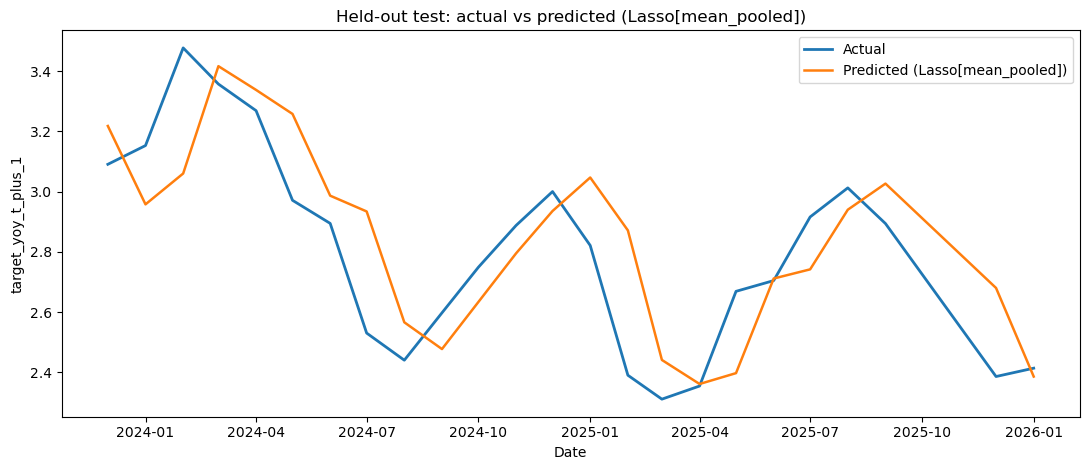

Saved: C:\Users\jijos\Desktop\261-Project\results\baselines\best_baseline_actual_vs_pred.png


In [8]:
# Plot strongest baseline (lowest test MAE)
best_model_name = baseline_df.iloc[0]["model"]

if best_model_name == "NaiveLast":
    y_pred_best = y_naive_last
elif best_model_name == "SeasonalNaive":
    y_pred_best = y_naive_seasonal
elif best_model_name.startswith("ARIMA"):
    y_pred_best = y_arima
else:
    y_pred_best = pred_store[best_model_name]

plot_df = pd.concat([
    y_test.rename("actual"),
    pd.Series(y_pred_best, name="pred")
], axis=1).dropna()

plt.figure(figsize=(11, 4.8))
plt.plot(plot_df.index, plot_df["actual"], label="Actual", linewidth=2)
plt.plot(plot_df.index, plot_df["pred"], label=f"Predicted ({best_model_name})", linewidth=1.8)
plt.title(f"Held-out test: actual vs predicted ({best_model_name})")
plt.xlabel("Date")
plt.ylabel(TARGET_NAME)
plt.legend()
plt.tight_layout()

plot_path = base_dir / "best_baseline_actual_vs_pred.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print("Saved:", plot_path)

## Verification checks
- final metrics come from held-out test dates only
- MASE scaling uses in-sample history only (`train + val`)

In [9]:
# Verify true held-out test evaluation for final baseline table
final_models = set(baseline_df["model"])
print("Final models:", final_models)
print("Test period:", y_test.index.min().date(), "to", y_test.index.max().date(), "| n=", len(y_test))
print("MASE scale history length:", len(y_insample), "(train+val)")

assert len(y_insample) == val_end, "MASE in-sample history should be pre-test only"
assert len(y_test) == (len(y_sr) - val_end), "Test segment mismatch"
assert all(col in baseline_df.columns for col in ["mae", "smape", "mase"]), "Missing metric columns"

print("Held-out test evaluation check: PASS")
print("MASE in-sample scaling check: PASS")

Final models: {'SeasonalNaive', 'NaiveLast', 'Lasso[mean_pooled]', 'Ridge[mean_pooled]', 'ARIMA(1, 0, 0)'}
Test period: 2023-12-01 to 2026-01-01 | n= 24
MASE scale history length: 371 (train+val)
Held-out test evaluation check: PASS
MASE in-sample scaling check: PASS
